# <center> Search for a Match </center>

In [1]:
import torch
import torchaudio
import torchvision.transforms as transforms
import librosa
import numpy as np
import cv2
import os
from scipy.optimize import linear_sum_assignment
from IPython.display import Audio , Video , HTML
import librosa
import librosa.display
import matplotlib.pyplot as plt


# Audio Data Analysis

## Preprocessing the Data and looking for Patterns

In [2]:
# Load and play the audio file
audio_path = '/kaggle/input/matching/dataset/audio_only/audio_only_ID_14.wav'
Audio(audio_path)

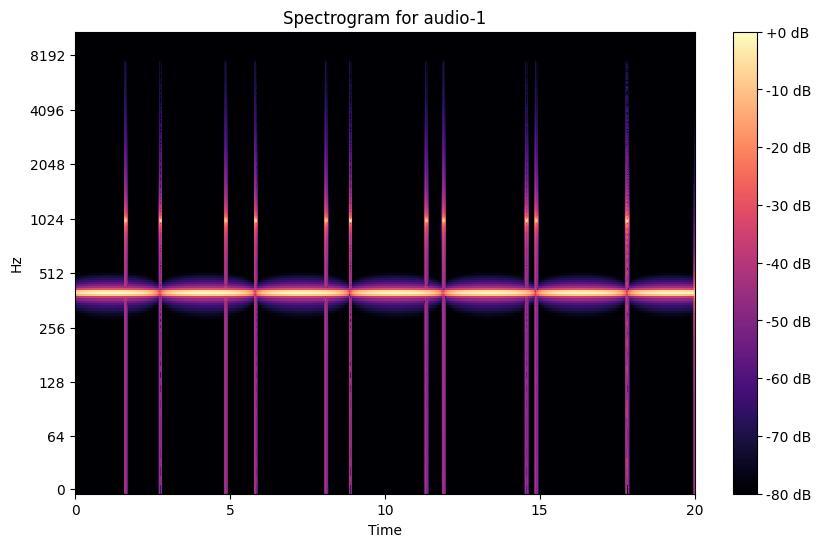

In [3]:
# Load the audio file
audio_path = '/kaggle/input/matching/dataset/audio_only/audio_only_ID_1.wav'
y, sr = librosa.load(audio_path)

# Compute the spectrogram (Short-Time Fourier Transform)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

# Plot the spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram for audio-1')
plt.show()


### Now these Beeps appear as Impulses in audio files which we can track

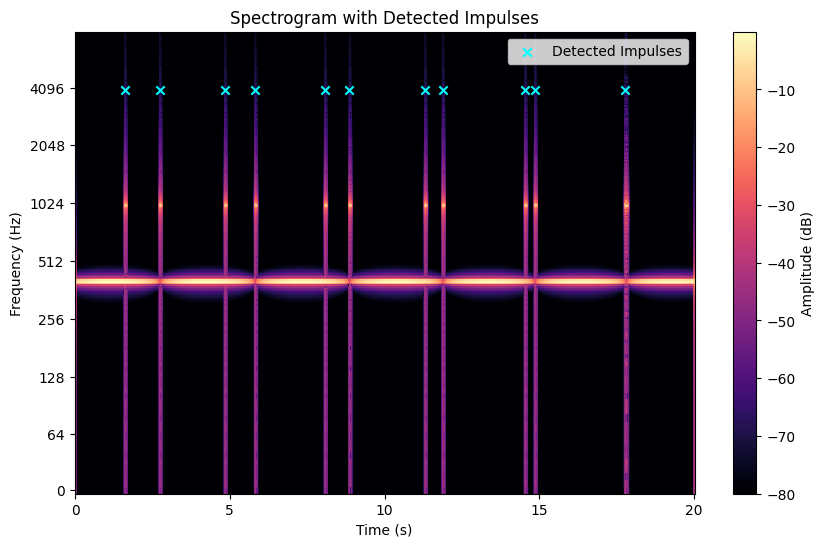

Impulse times (seconds): [ 1.619375   2.7335625  4.85175    5.817875   8.0855625  8.867875
 11.319375  11.8835625 14.5531875 14.867875  17.7840625]


In [4]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load the audio file
audio_path = "/kaggle/input/matching/dataset/audio_only/audio_only_ID_1.wav" 
y, sr = librosa.load(audio_path, sr=None)  # Load with original sample rate

# Compute amplitude envelope
amplitude_envelope = np.abs(y)

# Find peaks (impulses)
peaks, _ = find_peaks(amplitude_envelope, height=np.max(amplitude_envelope) * 0.5, distance=sr//10)

# Convert peak indices to time (seconds)
impulse_times = peaks / sr

# Compute spectrogram
D = librosa.stft(y)  # Short-Time Fourier Transform
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)  # Convert to dB scale

# Plot the spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', cmap='magma')
plt.colorbar(label="Amplitude (dB)")
plt.scatter(impulse_times, [sr // 4] * len(impulse_times), color='cyan', marker='x', label="Detected Impulses")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram with Detected Impulses")
plt.legend()
plt.show()

# Print impulse timestamps
print("Impulse times (seconds):", impulse_times)


### Function to detect Beeps

In [5]:
# Detect Beep Sounds in Audio
def detect_beeps(audio_path):
    y, sr = librosa.load(audio_path, sr=None)  # Load with original sample rate

    # Compute amplitude envelope
    amplitude_envelope = np.abs(y)
    
    # Find peaks (impulses)
    peaks, _ = find_peaks(amplitude_envelope, height=np.max(amplitude_envelope) * 0.5, distance=sr//10)
    
    # Convert peak indices to time (seconds)
    beep_times = peaks / sr

    return beep_times


# Video Data Analysis

## Preprocessing the Data and looking for Patterns

In [6]:
from IPython.display import Video

video_path = "/kaggle/input/matching/dataset/video_only/video_only_ID_1.mp4"
Video(video_path, embed=True)


 On Preprocessing , we find out that ball bounces off the boundaries but these boundaries are different from (0,0) and (height,weight)

## Locating the Boundaries

### White lines denote the left and right boundary whereas green boundary denotes the bottom .
### Ignoring the top boundary because in some of the videos , the ball passes out of the top boundary

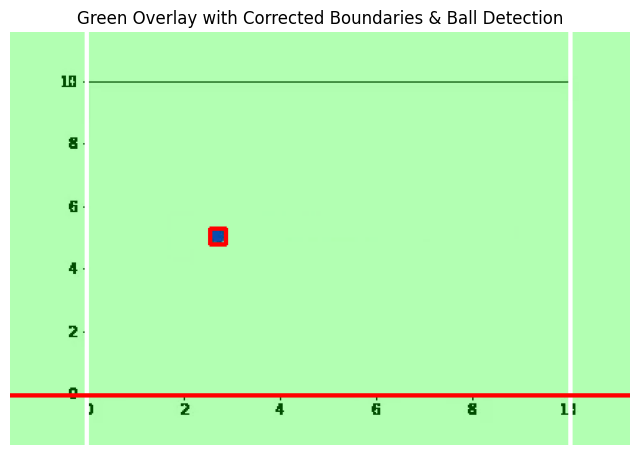

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set up paths
video_path = "/kaggle/input/matching/dataset/video_only/video_only_ID_1.mp4"  # Adjust if needed

# Load video
cap = cv2.VideoCapture(video_path)

frame_count = 0

# Define blue color range in HSV
lower_blue = np.array([90, 50, 50])    
upper_blue = np.array([130, 255, 255]) 

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    height, width = frame.shape[:2]

    # Convert to grayscale and apply Canny edge detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)  # Detect edges

    # Use Hough Line Transform to detect straight lines (axes)
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=100, minLineLength=50, maxLineGap=10)

    vertical_lines = []
    horizontal_lines = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            # Check if the line is vertical (x-coordinates are close)
            if abs(x1 - x2) < 10:
                vertical_lines.append((x1, y1, x2, y2))

            # Check if the line is horizontal (y-coordinates are close)
            if abs(y1 - y2) < 10:
                horizontal_lines.append((x1, y1, x2, y2))

    # Find the two main vertical and horizontal lines (axes)
    if vertical_lines:
        vertical_lines = sorted(vertical_lines, key=lambda v: v[0])  # Sort by x position
        boundary_left = vertical_lines[0][0]
        boundary_right = vertical_lines[-1][0]
    else:
        boundary_left, boundary_right = 0, width  # Default if not detected

    if horizontal_lines:
        horizontal_lines = sorted(horizontal_lines, key=lambda h: h[1])  # Sort by y position
        boundary_bottom = horizontal_lines[-1][1]  # Take the lowest horizontal line
    else:
        boundary_bottom = height  # Default if not detected

    # Convert frame to HSV and create mask for blue color
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Create a semi-transparent green overlay
    overlay = frame.copy()
    overlay[:] = (0, 255, 0)  # Green color
    alpha = 0.3  # Transparency level

    # Blend the original frame and the green overlay
    blended = cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0)

    # Find contours of the ball
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        if cv2.contourArea(cnt) > 50:  # Filter small objects
            x, y, w, h = cv2.boundingRect(cnt)
            cx, cy = x + w // 2, y + h // 2  # Center of the ball

            # Draw the detected ball on the blended frame
            cv2.rectangle(blended, (x, y), (x + w, y + h), (0, 0, 255), 2)  # Red box around ball

            # Draw detected boundaries
            cv2.line(blended, (boundary_left, 0), (boundary_left, height), (255, 255, 255), 2)  # Left boundary (White)
            cv2.line(blended, (boundary_right, 0), (boundary_right, height), (255, 255, 255), 2)  # Right boundary (White)
            cv2.line(blended, (0, boundary_bottom), (width, boundary_bottom), (0, 0, 255), 2)  # Bottom boundary (Red)

    if frame_count == 50:  # Plot frame #50 as an example
        cap.release()

        # Convert BGR to RGB for plotting
        blended_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

        # Plot the frame
        plt.figure(figsize=(8, 6))
        plt.imshow(blended_rgb)
        plt.axis("off")  # Hide axis
        plt.title("Green Overlay with Corrected Boundaries & Ball Detection")
        plt.show()
        break


### Function to Detect Boundaries

In [8]:
# Function to detect boundaries more robustly using multiple frames
def detect_boundaries(cap, num_frames=10):
    # Resize dimensions
    RESIZE_WIDTH = 400
    RESIZE_HEIGHT = 300
    
    boundaries = {'left': [], 'right': [], 'bottom': []}
    
    for _ in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            break
            
        frame = cv2.resize(frame, (RESIZE_WIDTH, RESIZE_HEIGHT))
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        
        lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=100, 
                               minLineLength=50, maxLineGap=10)
        
        if lines is not None:
            for line in lines:
                x1, y1, x2, y2 = line[0]
                
                # Vertical lines (potential left/right boundaries)
                if abs(x1 - x2) < 10:
                    x_pos = (x1 + x2) // 2
                    if x_pos < RESIZE_WIDTH // 2:  # Left side of frame
                        boundaries['left'].append(x_pos)
                    else:  # Right side of frame
                        boundaries['right'].append(x_pos)
                
                # Horizontal lines (potential bottom boundary)
                if abs(y1 - y2) < 10 and y1 > RESIZE_HEIGHT // 2:  # Bottom half
                    boundaries['bottom'].append(y1)
    
    # Calculate median values for more robustness against outliers
    boundary_left = int(np.median(boundaries['left'])) if boundaries['left'] else 0
    boundary_right = int(np.median(boundaries['right'])) if boundaries['right'] else RESIZE_WIDTH
    boundary_bottom = int(np.median(boundaries['bottom'])) if boundaries['bottom'] else RESIZE_HEIGHT
    
    return boundary_left, boundary_right, boundary_bottom


### Function for color detection of ball

In [9]:
# Define function for adaptive color detection
def find_ball_hsv_range(cap, num_frames=20):
    # Resize dimensions
    RESIZE_WIDTH = 400
    RESIZE_HEIGHT = 300
    
    h_values, s_values, v_values = [], [], []
    
    for _ in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            break
            
        frame = cv2.resize(frame, (RESIZE_WIDTH, RESIZE_HEIGHT))
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        
        # Use a base blue mask to find approximate ball location
        base_lower_blue = np.array([90, 50, 50])
        base_upper_blue = np.array([130, 255, 255])
        mask = cv2.inRange(hsv, base_lower_blue, base_upper_blue)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv2.contourArea(cnt) > 20:  # Filter small objects
                x, y, w, h = cv2.boundingRect(cnt)
                ball_region = hsv[y:y+h, x:x+w]
                
                # Only consider pixels that are not black in the mask
                ball_mask = mask[y:y+h, x:x+w]
                if np.sum(ball_mask > 0) > 10:  # Make sure we have enough pixels
                    h_values.extend(ball_region[:,:,0][ball_mask > 0])
                    s_values.extend(ball_region[:,:,1][ball_mask > 0])
                    v_values.extend(ball_region[:,:,2][ball_mask > 0])
    
    # Calculate ranges based on collected values
    if h_values:
        h_min, h_max = max(0, int(np.percentile(h_values, 10))), min(180, int(np.percentile(h_values, 90)))
        s_min, s_max = max(0, int(np.percentile(s_values, 10))), min(255, int(np.percentile(s_values, 90)))
        v_min, v_max = max(0, int(np.percentile(v_values, 10))), min(255, int(np.percentile(v_values, 90)))
        
        # Provide some margin
        h_min = max(0, h_min - 5)
        h_max = min(180, h_max + 5)
        s_min = max(0, s_min - 10)
        v_min = max(0, v_min - 10)
        
        return np.array([h_min, s_min, v_min]), np.array([h_max, s_max, v_max])
    
    # Fallback to default values
    return np.array([90, 50, 50]), np.array([130, 255, 255])


### Function to calculate velocity

In [10]:
# Function to calculate velocity vector
def calculate_velocity(positions):
    if len(positions) < 2:
        return 0, 0  # No velocity data yet
    
    # Calculate average velocity from last few positions
    dx = positions[-1][0] - positions[0][0]
    dy = positions[-1][1] - positions[0][1]
    frames = positions[-1][2] - positions[0][2]
    
    if frames == 0:
        return 0, 0
        
    return dx/frames, dy/frames


## An Example to show to how a collision is detected.

Adaptive HSV range: Lower [115  78 177], Upper [127 255 255]


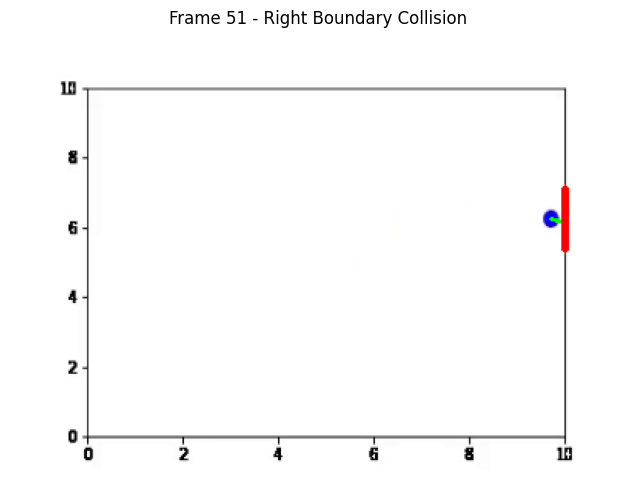

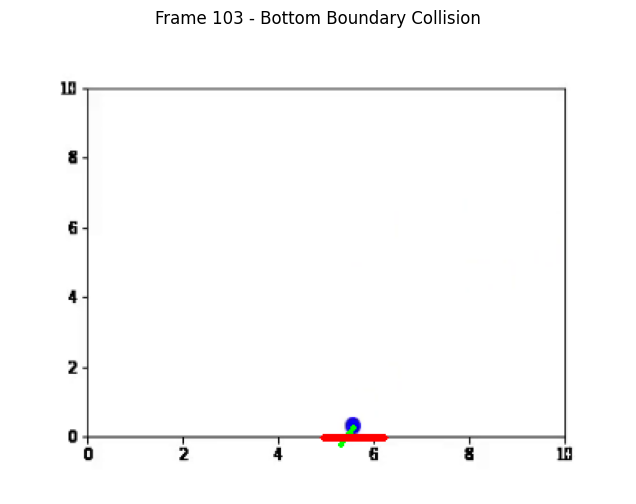

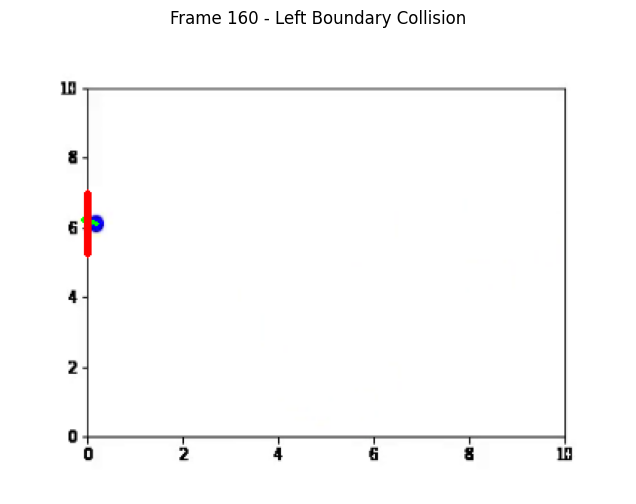

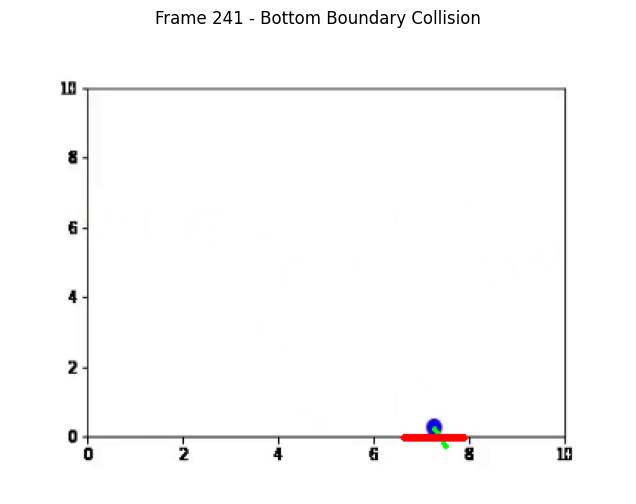

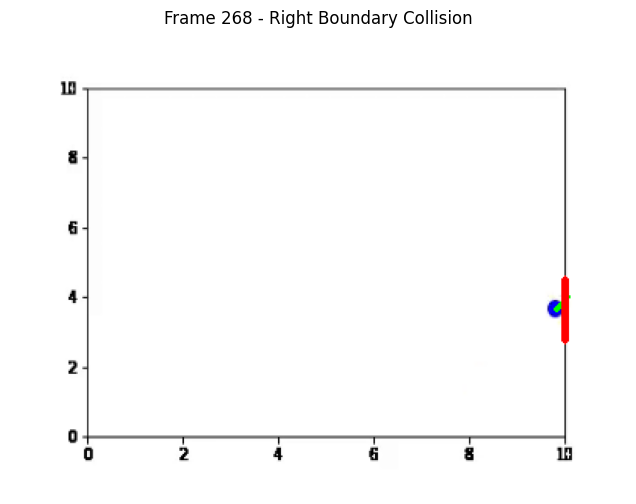

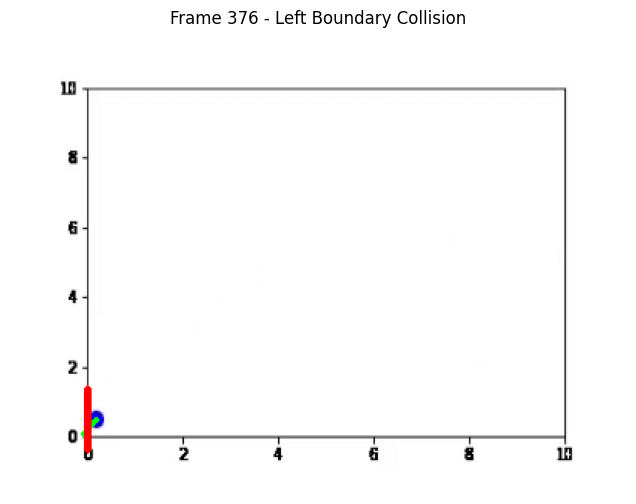

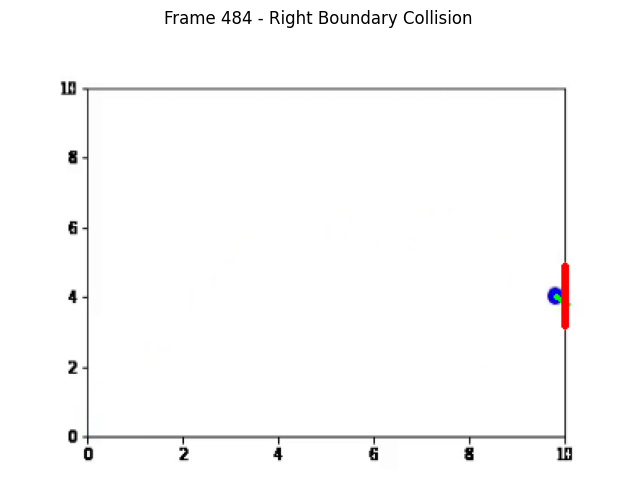

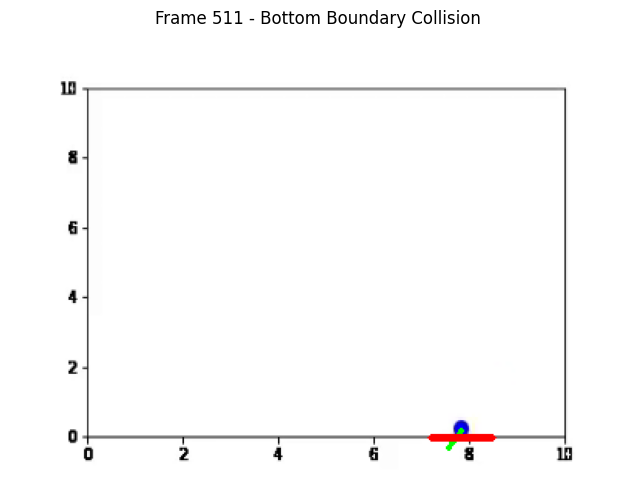

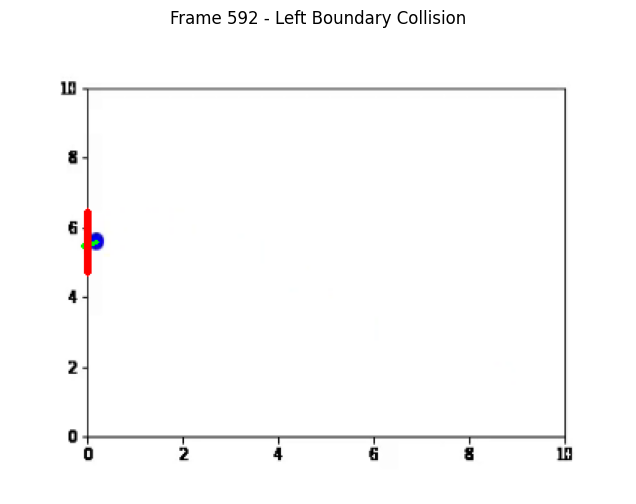

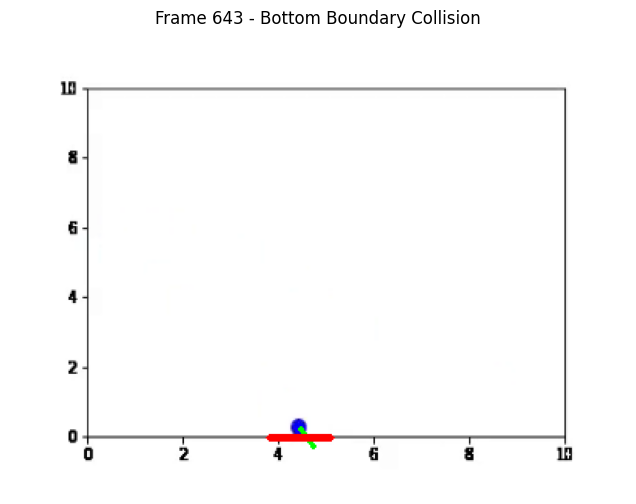

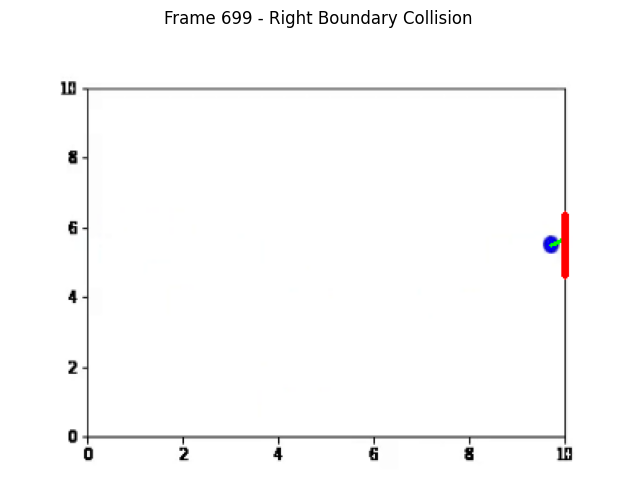

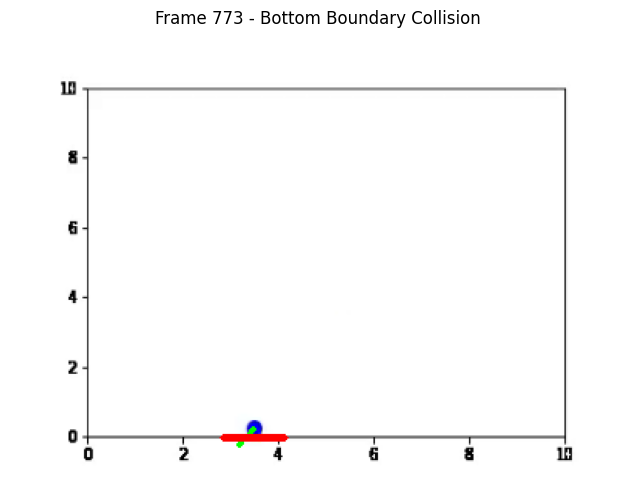

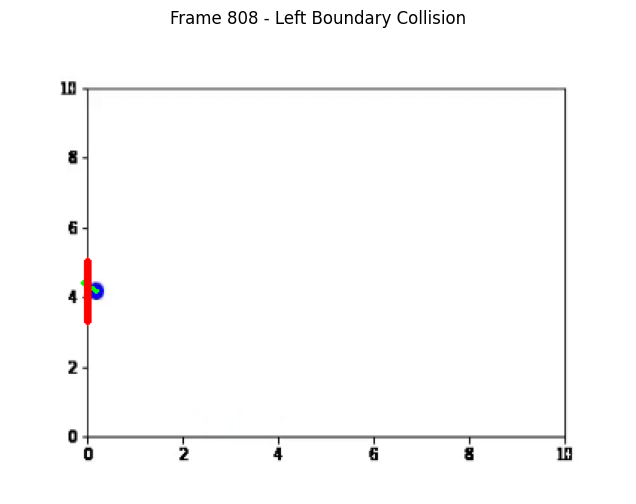

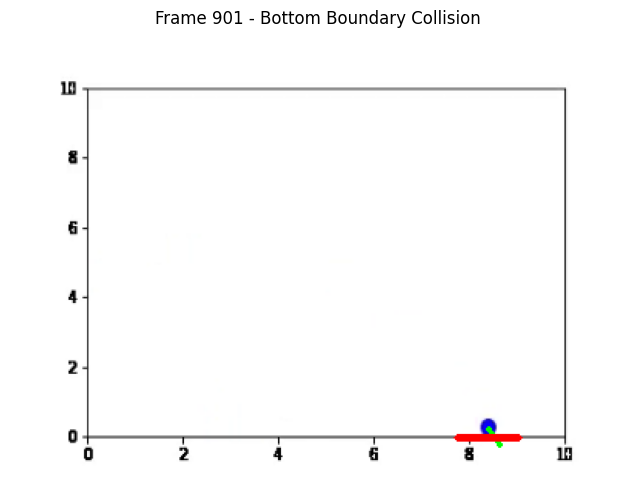

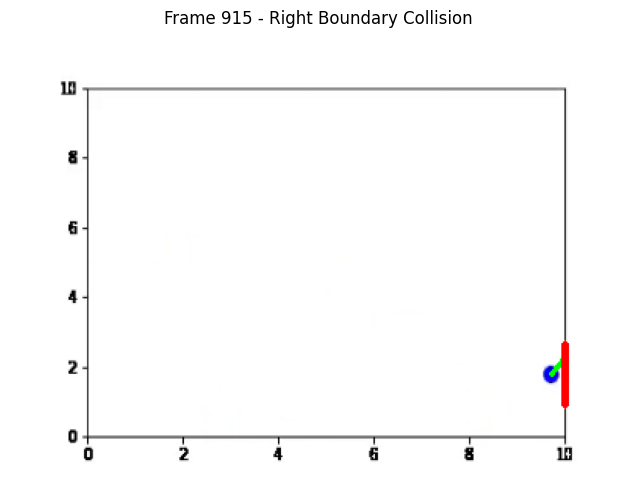

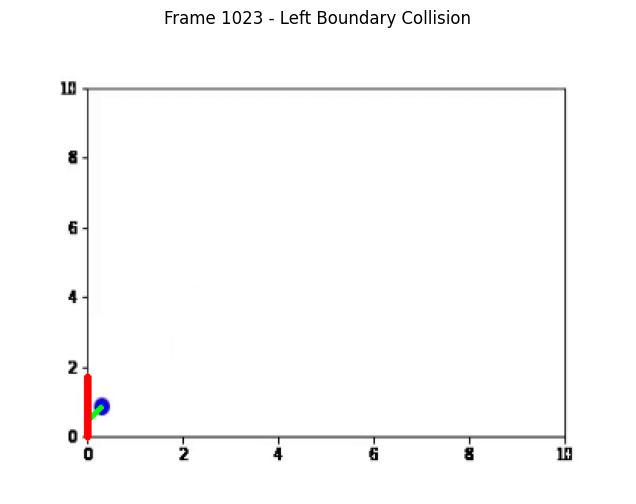

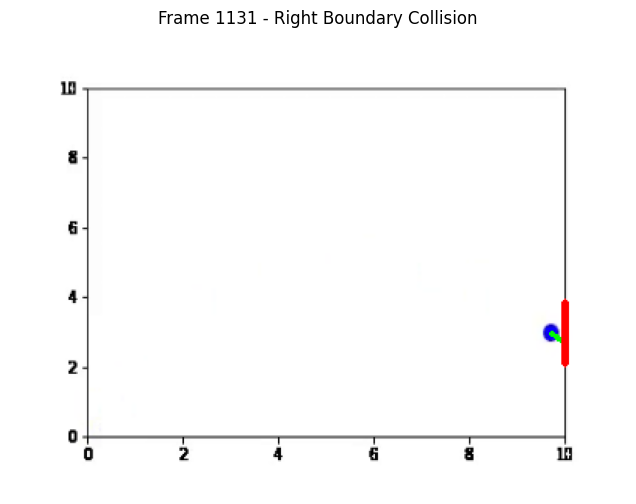

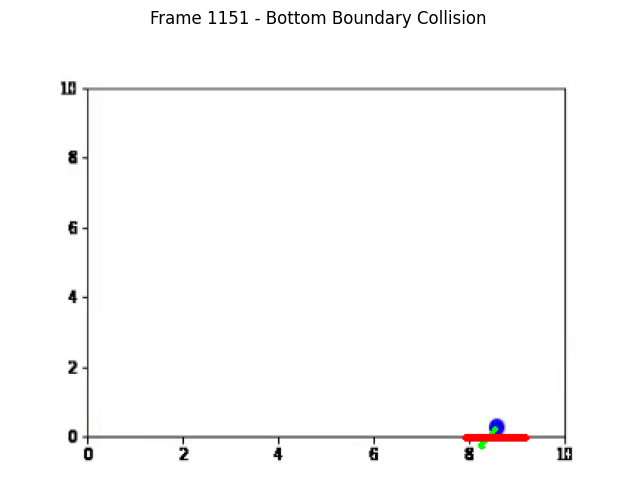

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Set up video path
video_path = "/kaggle/input/matching/dataset/video_only/video_only_ID_7.mp4"

# Load video
cap = cv2.VideoCapture(video_path)

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
video_duration = frame_count_total / fps

# Resize dimensions
RESIZE_WIDTH = 400
RESIZE_HEIGHT = 300

# Function to detect boundaries more robustly using multiple frames
def detect_boundaries(cap, num_frames=10):
    boundaries = {'left': [], 'right': [], 'bottom': []}
    
    for _ in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            break
            
        frame = cv2.resize(frame, (RESIZE_WIDTH, RESIZE_HEIGHT))
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        
        lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=100, 
                               minLineLength=50, maxLineGap=10)
        
        if lines is not None:
            for line in lines:
                x1, y1, x2, y2 = line[0]
                
                # Vertical lines (potential left/right boundaries)
                if abs(x1 - x2) < 10:
                    x_pos = (x1 + x2) // 2
                    if x_pos < RESIZE_WIDTH // 2:  # Left side of frame
                        boundaries['left'].append(x_pos)
                    else:  # Right side of frame
                        boundaries['right'].append(x_pos)
                
                # Horizontal lines (potential bottom boundary)
                if abs(y1 - y2) < 10 and y1 > RESIZE_HEIGHT // 2:  # Bottom half
                    boundaries['bottom'].append(y1)
    
    # Calculate median values for more robustness against outliers
    boundary_left = int(np.median(boundaries['left'])) if boundaries['left'] else 0
    boundary_right = int(np.median(boundaries['right'])) if boundaries['right'] else RESIZE_WIDTH
    boundary_bottom = int(np.median(boundaries['bottom'])) if boundaries['bottom'] else RESIZE_HEIGHT
    
    return boundary_left, boundary_right, boundary_bottom

# Reset video to start
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Detect boundaries using multiple frames
boundary_left, boundary_right, boundary_bottom = detect_boundaries(cap)

# Reset video again
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Visualization of boundaries on the first frame
ret, first_frame = cap.read()
if ret:
    first_frame = cv2.resize(first_frame, (RESIZE_WIDTH, RESIZE_HEIGHT))
    
    # Draw detected boundaries
    cv2.line(first_frame, (boundary_left, 0), (boundary_left, RESIZE_HEIGHT), (120, 255, 255), 2)
    cv2.line(first_frame, (boundary_right, 0), (boundary_right, RESIZE_HEIGHT), (120, 255, 255), 2)
    cv2.line(first_frame, (0, boundary_bottom), (RESIZE_WIDTH, boundary_bottom), (0, 0, 255), 2)
    
    first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

# Reset video to start again
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Define function for adaptive color detection
def find_ball_hsv_range(cap, num_frames=20):
    h_values, s_values, v_values = [], [], []
    
    for _ in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            break
            
        frame = cv2.resize(frame, (RESIZE_WIDTH, RESIZE_HEIGHT))
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        
        # Use a base blue mask to find approximate ball location
        base_lower_blue = np.array([90, 50, 50])
        base_upper_blue = np.array([130, 255, 255])
        mask = cv2.inRange(hsv, base_lower_blue, base_upper_blue)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv2.contourArea(cnt) > 20:  # Filter small objects
                x, y, w, h = cv2.boundingRect(cnt)
                ball_region = hsv[y:y+h, x:x+w]
                
                # Only consider pixels that are not black in the mask
                ball_mask = mask[y:y+h, x:x+w]
                if np.sum(ball_mask > 0) > 10:  # Make sure we have enough pixels
                    h_values.extend(ball_region[:,:,0][ball_mask > 0])
                    s_values.extend(ball_region[:,:,1][ball_mask > 0])
                    v_values.extend(ball_region[:,:,2][ball_mask > 0])
    
    # Calculate ranges based on collected values
    if h_values:
        h_min, h_max = max(0, int(np.percentile(h_values, 10))), min(180, int(np.percentile(h_values, 90)))
        s_min, s_max = max(0, int(np.percentile(s_values, 10))), min(255, int(np.percentile(s_values, 90)))
        v_min, v_max = max(0, int(np.percentile(v_values, 10))), min(255, int(np.percentile(v_values, 90)))
        
        # Provide some margin
        h_min = max(0, h_min - 5)
        h_max = min(180, h_max + 5)
        s_min = max(0, s_min - 10)
        v_min = max(0, v_min - 10)
        
        return np.array([h_min, s_min, v_min]), np.array([h_max, s_max, v_max])
    
    # Fallback to default values
    return np.array([90, 50, 50]), np.array([130, 255, 255])

# Reset video to start
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Get adaptive color range for the ball
lower_blue, upper_blue = find_ball_hsv_range(cap)
print(f"Adaptive HSV range: Lower {lower_blue}, Upper {upper_blue}")

# Reset video to start
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Ball position history for velocity calculation
ball_positions = deque(maxlen=5)
collision_frames = []
frame_count = 0

# Collision types (for detailed analysis)
collision_types = []

# Last collision frame tracking
last_collision_frame = -20  # Initialize to a negative value

# Function to calculate velocity vector
def calculate_velocity(positions):
    if len(positions) < 2:
        return 0, 0  # No velocity data yet
    
    # Calculate average velocity from last few positions
    dx = positions[-1][0] - positions[0][0]
    dy = positions[-1][1] - positions[0][1]
    frames = positions[-1][2] - positions[0][2]
    
    if frames == 0:
        return 0, 0
        
    return dx/frames, dy/frames

# Improved collision detection with velocity tracking
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    frame = cv2.resize(frame, (RESIZE_WIDTH, RESIZE_HEIGHT))
    
    # Find the ball
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    
    # Apply morphological operations to clean up the mask
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    ball_detected = False
    
    for cnt in contours:
        if cv2.contourArea(cnt) > 20:  # Filter small objects
            x, y, w, h = cv2.boundingRect(cnt)
            cx, cy = x + w // 2, y + h // 2  # Center of the ball
            radius = max(w, h) // 2  # Estimate radius
            
            ball_detected = True
            ball_positions.append((cx, cy, frame_count))
            
            # Calculate velocity if we have enough position history
            vx, vy = calculate_velocity(ball_positions)
            
            # Draw velocity vector (scaled for visibility)
            arrow_end_x = int(cx + vx * 3)
            arrow_end_y = int(cy + vy * 3)
            cv2.arrowedLine(frame, (cx, cy), (arrow_end_x, arrow_end_y), (0, 255, 0), 2)
            
            # Check for collisions using both position and velocity
            collision_type = None
            
            # Distance to boundaries
            dist_left = cx - boundary_left
            dist_right = boundary_right - cx
            dist_bottom = boundary_bottom - cy
            
            # Check if ball is about to collide (close to boundary and moving toward it)
            if dist_left < radius + 5 and vx < 0:  # Left boundary
                collision_type = "left"
            elif dist_right < radius + 5 and vx > 0:  # Right boundary
                collision_type = "right"
            elif dist_bottom < radius + 5 and vy > 0:  # Bottom boundary
                collision_type = "bottom"
            
            # Check if collision should be recorded (with cooldown)
            if collision_type and (frame_count - last_collision_frame > 10):  # 10 frame cooldown
                collision_frames.append(frame_count/fps)
                collision_types.append(collision_type)
                last_collision_frame = frame_count
                
                # Highlight the collision
                if collision_type == "left":
                    cv2.line(frame, (boundary_left, cy-20), (boundary_left, cy+20), (0, 0, 255), 4)
                elif collision_type == "right":
                    cv2.line(frame, (boundary_right, cy-20), (boundary_right, cy+20), (0, 0, 255), 4)
                elif collision_type == "bottom":
                    cv2.line(frame, (cx-20, boundary_bottom), (cx+20, boundary_bottom), (0, 0, 255), 4)
                
                # Save collision frame 
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                plt.figure(figsize=(8, 6))
                plt.imshow(frame_rgb)
                plt.axis("off")
                plt.title(f"Frame {frame_count} - {collision_type.capitalize()} Boundary Collision")
                plt.show()
            
            # Draw circle around the ball
            cv2.circle(frame, (cx, cy), radius, (0, 255, 0), 2)
            
    # Draw detected boundaries
    cv2.line(frame, (boundary_left, 0), (boundary_left, RESIZE_HEIGHT), (255, 255, 255), 2)
    cv2.line(frame, (boundary_right, 0), (boundary_right, RESIZE_HEIGHT), (255, 255, 255), 2)
    cv2.line(frame, (0, boundary_bottom), (RESIZE_WIDTH, boundary_bottom), (255, 255, 255), 2)
    
cap.release()


### Function to detect a collision

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Detect Ball Collisions in Video
def detect_collisions(video_path):
    # Load video
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_duration = frame_count_total / fps
    
    # Resize dimensions
    RESIZE_WIDTH = 400
    RESIZE_HEIGHT = 300
    
    
    # Reset video to start
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    
    # Detect boundaries using multiple frames
    boundary_left, boundary_right, boundary_bottom = detect_boundaries(cap)
    
    # Reset video again
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    
    # Get adaptive color range for the ball
    lower_blue, upper_blue = find_ball_hsv_range(cap)
    
    # Reset video to start
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    
    # Ball position history for velocity calculation
    ball_positions = deque(maxlen=5)
    collision_frames = []
    frame_count = 0
    
    # Collision types (for detailed analysis)
    collision_types = []
    
    # Last collision frame tracking
    last_collision_frame = -20  # Initialize to a negative value
    
    # Improved collision detection with velocity tracking
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
    
        frame_count += 1
        frame = cv2.resize(frame, (RESIZE_WIDTH, RESIZE_HEIGHT))
        
        # Find the ball
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower_blue, upper_blue)
        
        # Apply morphological operations to clean up the mask
        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        ball_detected = False
        
        for cnt in contours:
            if cv2.contourArea(cnt) > 20:  # Filter small objects
                x, y, w, h = cv2.boundingRect(cnt)
                cx, cy = x + w // 2, y + h // 2  # Center of the ball
                radius = max(w, h) // 2  # Estimate radius
                
                ball_detected = True
                ball_positions.append((cx, cy, frame_count))
                
                # Calculate velocity if we have enough position history
                vx, vy = calculate_velocity(ball_positions)
                
                # Draw velocity vector (scaled for visibility)
                arrow_end_x = int(cx + vx * 3)
                arrow_end_y = int(cy + vy * 3)
                cv2.arrowedLine(frame, (cx, cy), (arrow_end_x, arrow_end_y), (0, 255, 0), 2)
                
                # Check for collisions using both position and velocity
                collision_type = None
                
                # Distance to boundaries
                dist_left = cx - boundary_left
                dist_right = boundary_right - cx
                dist_bottom = boundary_bottom - cy
                
                # Check if ball is about to collide (close to boundary and moving toward it)
                if dist_left < radius + 5 and vx < 0:  # Left boundary
                    collision_type = "left"
                elif dist_right < radius + 5 and vx > 0:  # Right boundary
                    collision_type = "right"
                elif dist_bottom < radius + 5 and vy > 0:  # Bottom boundary
                    collision_type = "bottom"
                
                # Check if collision should be recorded (with cooldown)
                if collision_type and (frame_count - last_collision_frame > 10):  # 10 frame cooldown
                    collision_frames.append(frame_count/fps)
                    collision_types.append(collision_type)
                    last_collision_frame = frame_count
                    
                    # Highlight the collision
                    if collision_type == "left":
                        cv2.line(frame, (boundary_left, cy-20), (boundary_left, cy+20), (0, 0, 255), 4)
                    elif collision_type == "right":
                        cv2.line(frame, (boundary_right, cy-20), (boundary_right, cy+20), (0, 0, 255), 4)
                    elif collision_type == "bottom":
                        cv2.line(frame, (cx-20, boundary_bottom), (cx+20, boundary_bottom), (0, 0, 255), 4)
                    
                # Draw circle around the ball
                cv2.circle(frame, (cx, cy), radius, (0, 255, 0), 2)
                
        # Draw detected boundaries
        cv2.line(frame, (boundary_left, 0), (boundary_left, RESIZE_HEIGHT), (255, 255, 255), 2)
        cv2.line(frame, (boundary_right, 0), (boundary_right, RESIZE_HEIGHT), (255, 255, 255), 2)
        cv2.line(frame, (0, boundary_bottom), (RESIZE_WIDTH, boundary_bottom), (255, 255, 255), 2)
           
    cap.release()
    return collision_frames


In [14]:
# Load Dataset
audio_dir = "/kaggle/input/matching/dataset/audio_only"
video_dir = "/kaggle/input/matching/dataset/video_only"

audio_files = sorted(os.listdir(audio_dir))
video_files = sorted(os.listdir(video_dir))

audio_events = {f: detect_beeps(os.path.join(audio_dir, f)) for f in audio_files}
video_events = {f: detect_collisions(os.path.join(video_dir, f)) for f in video_files}


### Now we have instances where the ball collides with the boundary and the instances where there is a beep.

### Using linear_sum_assignment from Scipy for optimal Matching

In [15]:
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.neighbors import NearestNeighbors

def match_audio_video(audio_files, video_files, audio_events, video_events):
    best_matches = {}
    distance_matrix = []

    nn_audio = NearestNeighbors(n_neighbors=1, metric='euclidean')
    
    for audio_file in audio_files:
        audio_times = np.unique(audio_events[audio_file])
        if len(audio_times) == 0:
            distance_matrix.append([1e9] * len(video_files))  # Large cost for empty events
            continue

        nn_audio.fit(audio_times.reshape(-1, 1))

        audio_distances = []
        for video_file in video_files:
            video_times = np.unique(video_events[video_file])
            if len(video_times) == 0:
                audio_distances.append(1e9)  # Large cost for empty events
                continue

            distances, _ = nn_audio.kneighbors(video_times.reshape(-1, 1))
            mean_distance = np.mean(distances)
            audio_distances.append(mean_distance)

        distance_matrix.append(audio_distances)

    distance_matrix = np.array(distance_matrix)

    row_ind, col_ind = linear_sum_assignment(distance_matrix)

    for audio_idx, video_idx in zip(row_ind, col_ind):
        best_matches[audio_files[audio_idx]] = video_files[video_idx]

    return best_matches

matches = match_audio_video(audio_files,video_files,audio_events, video_events)
print("Matching Results:")
for audio, video in matches.items():
    print(f"{audio} -> {video}")


Matching Results:
audio_only_ID_1.wav -> video_only_ID_2.mp4
audio_only_ID_10.wav -> video_only_ID_42.mp4
audio_only_ID_11.wav -> video_only_ID_24.mp4
audio_only_ID_12.wav -> video_only_ID_28.mp4
audio_only_ID_13.wav -> video_only_ID_14.mp4
audio_only_ID_14.wav -> video_only_ID_7.mp4
audio_only_ID_15.wav -> video_only_ID_38.mp4
audio_only_ID_16.wav -> video_only_ID_18.mp4
audio_only_ID_17.wav -> video_only_ID_34.mp4
audio_only_ID_18.wav -> video_only_ID_4.mp4
audio_only_ID_19.wav -> video_only_ID_5.mp4
audio_only_ID_2.wav -> video_only_ID_16.mp4
audio_only_ID_20.wav -> video_only_ID_11.mp4
audio_only_ID_21.wav -> video_only_ID_26.mp4
audio_only_ID_22.wav -> video_only_ID_45.mp4
audio_only_ID_23.wav -> video_only_ID_10.mp4
audio_only_ID_24.wav -> video_only_ID_12.mp4
audio_only_ID_25.wav -> video_only_ID_39.mp4
audio_only_ID_26.wav -> video_only_ID_35.mp4
audio_only_ID_27.wav -> video_only_ID_40.mp4
audio_only_ID_28.wav -> video_only_ID_25.mp4
audio_only_ID_29.wav -> video_only_ID_30.mp

In [16]:
import pandas as pd

# Store Hungarian matches in a DataFrame
df = pd.DataFrame(list(matches.items()), columns=["AUDIO", "VIDEO"])

# Sorting by numerical part of 'video' column
df_sorted = df.sort_values(by="AUDIO", key=lambda x: x.str.extract(r'(\d+)')[0].astype(int))

df_sorted.to_csv("final_matches.csv", index=False)
print("Saved matches to final_matches.csv")


Saved matches to final_matches.csv
